# Football Match Analysis

This notebook is a first exploration of football matches since 2000. I start by loading the match data and checking the available columns.

In [1]:
import pandas as pd
raw_df = pd.read_csv('data/Matches.csv')

/tmp/ipykernel_79302/1280493266.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('data/Matches.csv')


In [2]:
raw_df.dtypes

Division        object
MatchDate       object
MatchTime       object
HomeTeam        object
AwayTeam        object
HomeElo        float64
AwayElo        float64
Form3Home      float64
Form5Home      float64
Form3Away      float64
Form5Away      float64
FTHome         float64
FTAway         float64
FTResult        object
HTHome         float64
HTAway         float64
HTResult        object
HomeShots      float64
AwayShots      float64
HomeTarget     float64
AwayTarget     float64
HomeFouls      float64
AwayFouls      float64
HomeCorners    float64
AwayCorners    float64
HomeYellow     float64
AwayYellow     float64
HomeRed        float64
AwayRed        float64
OddHome        float64
OddDraw        float64
OddAway        float64
MaxHome        float64
MaxDraw        float64
MaxAway        float64
Over25         float64
Under25        float64
MaxOver25      float64
MaxUnder25     float64
HandiSize      float64
HandiHome      float64
HandiAway      float64
C_LTH          float64
C_LTA      

In [3]:
raw_df.head(3)

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Selecting useful columns

The raw dataset already contains some pre-computed features, such as betting odds and form indicators. Since I want to work more directly with the match information, I keep only the basic match, score, and card statistics here.

In [4]:
keep_columns = [
    'Division',
    'MatchDate',
    'MatchTime',
    'HomeTeam',
    'AwayTeam',
    'FTHome',
    'FTAway',
    'FTResult',
    'HTHome',
    'HTAway',
    'HTResult',
    'HomeShots',
    'AwayShots',
    'HomeTarget',
    'AwayTarget',
    'HomeCorners',
    'AwayCorners',
    'HomeYellow',
    "AwayYellow",
    'HomeRed',
    'AwayRed',
]

df = raw_df[keep_columns]

## Adding Elo ratings

In [5]:
# read the elos
elos_df = pd.read_csv("data/EloRatings.csv")

# inspect columns
elos_df.dtypes

date        object
club        object
country     object
elo        float64
dtype: object

In [6]:
elos_df.isna().sum()

date       0
club       0
country    0
elo        0
dtype: int64

In [7]:
elos_df.head()

,date,club,country,elo
0,2000-07-01,Aachen,GER,1453.60
1,2000-07-01,Aalborg,DEN,1482.61
2,2000-07-01,Aalst,BEL,1337.53
3,2000-07-01,Aarhus,DEN,1381.46
4,2000-07-01,Aberdeen,SCO,1360.43


Joining the Elo data is a bit more complicated than a standard merge. Two things need to be checked:
1. Some clubs may have the same name in different countries.
2. Elo ratings are not available for every match day, so I use the closest previous rating. This avoids using information from after the match.

In [8]:
# check if there are clubs with the same name in different countries
'''
clubs = elos_df['club'].unique()
for c in clubs:
    countries = elos_df[elos_df['club'] == c]['country'].unique()
    if len(countries) > 1:
        print(f"Double occurrence of {c}, present in countries {countries}")
'''

## this was the naive way to implement this (very inefficient), it takes around 25 seconds to execute on a laptop

'\nclubs = elos_df[\'club\'].unique()\nfor c in clubs:\n    countries = elos_df[elos_df[\'club\'] == c][\'country\'].unique()\n    if len(countries) > 1:\n        print(f"Double occurrence of {c}, present in countries {countries}")\n'

In [9]:
# we use the groupby function for more efficiency, it groups the rows by club
# then we check the unique countries for each 'club group'
club_countries = elos_df.groupby("club")["country"].unique()

# duplicates have more than one country assigned
duplicates = club_countries[club_countries.str.len() > 1]

for club, countries in duplicates.items():
    print(f"Double occurrence of {club}, present in countries {countries}")

## this only takes 0.1 seconds

In [10]:
# now we merge the datasets
# to this end, we sort based on clubs and dates, then we join using the
# first elo rating that was recorded before the match date
df['MatchDate'] = pd.to_datetime(df['MatchDate'])
elos_df['date'] = pd.to_datetime(elos_df['date'])
elos_df.rename(columns={"date":"MatchDate"}, inplace=True)

# merge home team elo
elos_df.rename(columns={'club':'HomeTeam'}, inplace=True)
df = df.sort_values(['MatchDate', 'MatchDate'])
elos_df = elos_df.sort_values(['MatchDate', 'MatchDate'])
df = pd.merge_asof(
    df, elos_df,
    on = 'MatchDate',
    by = 'HomeTeam',
    direction='backward'
)
df.rename(columns={
    "elo":"HomeElo",
    "country":"HomeCountry"
}, inplace=True)

# merge away team elo
elos_df.rename(columns={'HomeTeam':'AwayTeam'}, inplace=True)
df = df.sort_values(['MatchDate', 'AwayTeam'])
elos_df = elos_df.sort_values(['MatchDate', 'AwayTeam'])
df = pd.merge_asof(
    df, elos_df,
    on = 'MatchDate',
    by = 'AwayTeam',
    direction='backward'
)
df.rename(columns={
    "elo":"AwayElo",
    "country":"AwayCountry"
}, inplace=True)

/tmp/ipykernel_79302/3158064884.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MatchDate'] = pd.to_datetime(df['MatchDate'])


In [11]:
# check if the joins worked:
df

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,FTHome,FTAway,FTResult,HTHome,HTAway,...,HomeCorners,AwayCorners,HomeYellow,AwayYellow,HomeRed,AwayRed,HomeCountry,HomeElo,AwayCountry,AwayElo
0,F2,2000-07-28,NaN,Wasquehal,Nancy,0.0,1.0,A,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,FRA,1465.08,FRA,1633.80
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,3.0,1.0,H,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,FRA,1714.89,FRA,1642.51
2,F1,2000-07-28,NaN,Marseille,Troyes,3.0,1.0,H,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,FRA,1686.34,FRA,1586.57
3,F2,2000-07-29,NaN,Niort,Angers,3.0,2.0,H,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,FRA,1469.16,FRA,1422.21
4,F1,2000-07-29,NaN,Toulouse,Bastia,0.0,1.0,A,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,FRA,1551.65,FRA,1656.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230552,SP2,2025-06-01,17:30:00,Huesca,Eldense,3.0,2.0,H,1.0,2.0,...,4.0,4.0,0.0,1.0,0.0,0.0,ESP,1496.86,ESP,1423.86
230553,SP2,2025-06-01,17:30:00,Santander,Granada,2.0,1.0,H,1.0,1.0,...,5.0,1.0,4.0,4.0,0.0,1.0,ESP,1527.51,ESP,1537.00
230554,T1,2025-06-01,17:00:00,Samsunspor,Kayserispor,2.0,1.0,H,0.0,0.0,...,12.0,4.0,5.0,3.0,0.0,0.0,TUR,1431.06,TUR,1394.59
230555,SP2,2025-06-01,17:30:00,Cartagena,Mirandes,1.0,3.0,A,1.0,2.0,...,4.0,6.0,3.0,1.0,0.0,0.0,ESP,1339.21,ESP,1544.15


## Handling missing values

Next, I check which values are missing after the joins.

In [12]:
df.isna().sum()

Division            0
MatchDate           0
MatchTime      131485
HomeTeam            0
AwayTeam            0
FTHome              3
FTAway              3
FTResult            3
HTHome          54580
HTAway          54580
HTResult        54580
HomeShots      115822
AwayShots      115819
HomeTarget     116628
AwayTarget     116625
HomeCorners    116194
AwayCorners    116194
HomeYellow     111259
AwayYellow     111258
HomeRed        111258
AwayRed        111260
HomeCountry     78348
HomeElo         78348
AwayCountry     78402
AwayElo         78402
dtype: int64

In [13]:
# inspect 3 matches where no result is given. For other missing values,
# we can still infer something from the final result
condition = df['FTResult'].isna()
df[condition]

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,FTHome,FTAway,FTResult,HTHome,HTAway,...,HomeCorners,AwayCorners,HomeYellow,AwayYellow,HomeRed,AwayRed,HomeCountry,HomeElo,AwayCountry,AwayElo
112576,G1,2015-05-10,NaN,Niki Volos,OFI,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,GRE,1256.36,GRE,1276.54
130317,BRA,2016-11-12,19:00:00,Chapecoense-SC,Atletico-MG,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159235,G1,2019-03-17,NaN,Panathinaikos,Olympiakos,NaN,NaN,NaN,0.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,GRE,1440.16,GRE,1625.58


In [14]:
# remove these columns since they don't contain any important information and it is also only a tiny fraction of all data
if condition.any():
    df = df[~condition]
df['FTResult'].isna().sum()

np.int64(0)

There are still missing values in some columns. Whether to drop or impute them depends on the question, so I handle them directly before each analysis.

## First analysis: Do aggressive teams tend to win or lose?

In [15]:
# drop rows where we don't have sufficient information
df = df[~df['HomeYellow'].isna()]
df = df[~df['AwayYellow'].isna()]
df = df[~df['HomeRed'].isna()]
df = df[~df['AwayRed'].isna()]
df.head()

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,FTHome,FTAway,FTResult,HTHome,HTAway,...,HomeCorners,AwayCorners,HomeYellow,AwayYellow,HomeRed,AwayRed,HomeCountry,HomeElo,AwayCountry,AwayElo
39,D1,2000-08-11,NaN,Dortmund,Hansa Rostock,1.0,0.0,H,0.0,0.0,...,7.0,3.0,1.0,5.0,0.0,0.0,GER,1646.19,GER,1631.68
40,D2,2000-08-11,NaN,Hannover,Nurnberg,1.0,1.0,D,0.0,0.0,...,NaN,NaN,1.0,1.0,0.0,0.0,GER,1504.93,GER,1579.35
41,D2,2000-08-11,NaN,Stuttgarter K,Oberhausen,1.0,0.0,H,1.0,0.0,...,NaN,NaN,2.0,1.0,0.0,0.0,NaN,NaN,GER,1529.77
44,E1,2000-08-12,NaN,QPR,Birmingham,0.0,0.0,D,0.0,0.0,...,2.0,6.0,1.0,3.0,0.0,0.0,ENG,1509.88,ENG,1560.75
45,D1,2000-08-12,NaN,Kaiserslautern,Bochum,0.0,1.0,A,0.0,0.0,...,5.0,5.0,1.0,0.0,0.0,0.0,GER,1669.80,GER,1587.32


In [16]:
df['FTResult_label'] = df['FTResult'].astype('category').cat.codes
df = pd.get_dummies(df, columns=['FTResult'], dtype=int) # creates one column per result (winning away/home/draw)
df

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,FTHome,FTAway,HTHome,HTAway,HTResult,...,HomeRed,AwayRed,HomeCountry,HomeElo,AwayCountry,AwayElo,FTResult_label,FTResult_A,FTResult_D,FTResult_H
39,D1,2000-08-11,NaN,Dortmund,Hansa Rostock,1.0,0.0,0.0,0.0,D,...,0.0,0.0,GER,1646.19,GER,1631.68,2,0,0,1
40,D2,2000-08-11,NaN,Hannover,Nurnberg,1.0,1.0,0.0,0.0,D,...,0.0,0.0,GER,1504.93,GER,1579.35,1,0,1,0
41,D2,2000-08-11,NaN,Stuttgarter K,Oberhausen,1.0,0.0,1.0,0.0,H,...,0.0,0.0,NaN,NaN,GER,1529.77,2,0,0,1
44,E1,2000-08-12,NaN,QPR,Birmingham,0.0,0.0,0.0,0.0,D,...,0.0,0.0,ENG,1509.88,ENG,1560.75,1,0,1,0
45,D1,2000-08-12,NaN,Kaiserslautern,Bochum,0.0,1.0,0.0,0.0,D,...,0.0,0.0,GER,1669.80,GER,1587.32,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230552,SP2,2025-06-01,17:30:00,Huesca,Eldense,3.0,2.0,1.0,2.0,A,...,0.0,0.0,ESP,1496.86,ESP,1423.86,2,0,0,1
230553,SP2,2025-06-01,17:30:00,Santander,Granada,2.0,1.0,1.0,1.0,D,...,0.0,1.0,ESP,1527.51,ESP,1537.00,2,0,0,1
230554,T1,2025-06-01,17:00:00,Samsunspor,Kayserispor,2.0,1.0,0.0,0.0,D,...,0.0,0.0,TUR,1431.06,TUR,1394.59,2,0,0,1
230555,SP2,2025-06-01,17:30:00,Cartagena,Mirandes,1.0,3.0,1.0,2.0,A,...,0.0,0.0,ESP,1339.21,ESP,1544.15,0,1,0,0


In [17]:
# check basic hypotheses:
hypotheses = [
    ('HomeYellow', 'If there was a red, the might have been a yellow?'),
    ('FTResult_H', 'If the home team got a red card, it is more likely to lose?'),
    ('HomeElo', 'More skilled teams foul less?')
]
for (h,exp) in hypotheses:
    print(exp)
    print(df[['HomeRed',h]].corr(method='pearson'))

If there was a red, the might have been a yellow?
             HomeRed  HomeYellow
HomeRed     1.000000    0.139521
HomeYellow  0.139521    1.000000
If the home team got a red card, it is more likely to lose?
             HomeRed  FTResult_H
HomeRed     1.000000   -0.109781
FTResult_H -0.109781    1.000000
More skilled teams foul less?
          HomeRed   HomeElo
HomeRed  1.000000 -0.009294
HomeElo -0.009294  1.000000


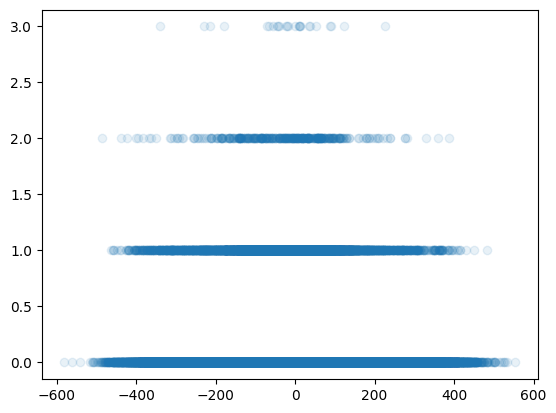

In [18]:
# check whether less skilled teams foul more against more skilled teams?
df['elo_diff']  = df['HomeElo'] - df['AwayElo']
df[['HomeRed', 'elo_diff']].corr(method='pearson')

import matplotlib.pyplot as plt

plt.scatter(df["elo_diff"], df["HomeRed"], alpha=0.1)

Football results are noisy, so I do not expect very high correlations here. The first checks suggest:
- Teams with more yellow cards also tend to have more red cards.
- After a home red card, the chance of a home win decreases slightly.
- In this data, the relationship between Elo difference and home red cards looks weak.

## Does Elo predict the winning team?

In [19]:
df[['HomeElo', 'FTResult_H']].corr()

,HomeElo,FTResult_H
HomeElo,1.000000,0.132102
FTResult_H,0.132102,1.000000


In [20]:
df[['AwayElo', 'FTResult_A']].corr()

,AwayElo,FTResult_A
AwayElo,1.000000,0.104318
FTResult_A,0.104318,1.000000


This suggests that Elo has some signal for the winner, but the relationship is not very strong on its own.

## What changes when the home team gets a red card?

In [21]:
num_red_cards = df['HomeRed'].unique() # what are the possible values of red cards?
for num in num_red_cards:
    df_red = df[df['HomeRed'] == num].copy()
    print(f"When having received {num} red card(s), the correlation in {len(df_red)} matches is:")
    print(df_red[['HomeElo', 'FTResult_H']].corr())


When having received 0.0 red card(s), the correlation in 109540 matches is:
             HomeElo  FTResult_H
HomeElo     1.000000    0.135927
FTResult_H  0.135927    1.000000
When having received 1.0 red card(s), the correlation in 9235 matches is:
             HomeElo  FTResult_H
HomeElo     1.000000    0.078612
FTResult_H  0.078612    1.000000
When having received 2.0 red card(s), the correlation in 493 matches is:
             HomeElo  FTResult_H
HomeElo     1.000000    0.087404
FTResult_H  0.087404    1.000000
When having received 3.0 red card(s), the correlation in 28 matches is:
             HomeElo  FTResult_H
HomeElo     1.000000    0.131485
FTResult_H  0.131485    1.000000


Interpretation:
- Without a red card, the stronger home team is more likely to win.
- With one or two red cards, this relationship becomes weaker.
- For three red cards, the correlation rises again, but this case is very rare, so the estimate is not very reliable.

## Building a simple prediction model

In [22]:
df_engineered = df.copy()
for col in ['Division', 'HomeCountry', 'AwayCountry']: # convert categorical into numbers
    df_engineered[col] = df_engineered[col].astype('category').cat.codes
print(df_engineered)

        Division  MatchDate MatchTime        HomeTeam       AwayTeam  FTHome  \
39             1 2000-08-11       NaN        Dortmund  Hansa Rostock     1.0   
40             2 2000-08-11       NaN        Hannover       Nurnberg     1.0   
41             2 2000-08-11       NaN   Stuttgarter K     Oberhausen     1.0   
44             4 2000-08-12       NaN             QPR     Birmingham     0.0   
45             1 2000-08-12       NaN  Kaiserslautern         Bochum     0.0   
...          ...        ...       ...             ...            ...     ...   
230552        20 2025-06-01  17:30:00          Huesca        Eldense     3.0   
230553        20 2025-06-01  17:30:00       Santander        Granada     2.0   
230554        21 2025-06-01  17:00:00      Samsunspor    Kayserispor     2.0   
230555        20 2025-06-01  17:30:00       Cartagena       Mirandes     1.0   
230556        20 2025-06-01  17:30:00         Almeria       Tenerife     2.0   

        FTAway  HTHome  HTAway HTResult

In [23]:
df_engineered.dtypes

Division                    int8
MatchDate         datetime64[ns]
MatchTime                 object
HomeTeam                  object
AwayTeam                  object
FTHome                   float64
FTAway                   float64
HTHome                   float64
HTAway                   float64
HTResult                  object
HomeShots                float64
AwayShots                float64
HomeTarget               float64
AwayTarget               float64
HomeCorners              float64
AwayCorners              float64
HomeYellow               float64
AwayYellow               float64
HomeRed                  float64
AwayRed                  float64
HomeCountry                 int8
HomeElo                  float64
AwayCountry                 int8
AwayElo                  float64
FTResult_label              int8
FTResult_A                 int64
FTResult_D                 int64
FTResult_H                 int64
elo_diff                 float64
dtype: object

In [24]:
# remove games where we don't have an elo given for either team
df_engineered = df_engineered.dropna(subset=['HomeElo', 'AwayElo'])
print(df_engineered[['Division', 'MatchDate', 'HomeRed', 'AwayRed', 'HomeCountry', 'AwayCountry', 'AwayElo', 'HomeElo', 'elo_diff']].isna().sum())
print(df_engineered['FTResult_label'].isna().sum())

Division       0
MatchDate      0
HomeRed        0
AwayRed        0
HomeCountry    0
AwayCountry    0
AwayElo        0
HomeElo        0
elo_diff       0
dtype: int64
0


In [25]:
# convert matchdate into year, month, day of week columns
df_engineered['MatchYear'] = df_engineered.MatchDate.dt.year
df_engineered['MatchMonth'] = df_engineered.MatchDate.dt.month
df_engineered['MatchDOW'] = df_engineered.MatchDate.dt.day_of_week

In [26]:
# predict the winning team
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_features = ['HomeRed', 'AwayRed', 'elo_diff']
X = df_engineered[X_features]
# normalize:
X = (X-X.mean()) / X.std()
y = df_engineered['FTResult_label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression().fit(X_train, y_train)

print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.5112434847356664
0.5116750059566357
